# Flipkart Product Pricing & Discount Analysis

## Notebook 2: Exploratory Data Analysis (EDA)

---

### Notebook Objective

This notebook explores the cleaned Flipkart product catalogue to uncover pricing patterns, category distribution, discount strategies, brand presence, and rating availability.

The objective is to transform the cleaned dataset into meaningful business insights that support pricing decisions, catalogue management, and dashboard development.

# EDA Objectives

The exploratory analysis aims to answer the following questions:

- Which product categories dominate the catalogue?
- Which categories have the highest average retail prices?
- How are products distributed across different price segments?
- Which brands contribute the highest number of listings?
- How do discount strategies vary across categories and price ranges?
- Is the available rating data sufficient for meaningful customer satisfaction analysis?

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["figure.dpi"] = 120

In [2]:
# ==========================================================
# Load Clean Dataset
# ==========================================================

df = pd.read_csv("../data/cleaned_flipkart_dataset.csv")

print("="*60)
print("Clean Dataset Loaded Successfully")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.head()

Clean Dataset Loaded Successfully
Rows    : 15827
Columns : 10


,brand,product_name,product_category_tree,product_rating,retail_price,discounted_price,discount_percentage,main_category,sub_category,price_bucket
0,Alisha,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",NaN,999.0,379.0,62.062062,Clothing,Women's Clothing,<₹500
1,FabHomeDecor,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",NaN,32157.0,22646.0,29.576764,Furniture,Living Room Furniture,₹5K+
2,AW,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",NaN,999.0,499.0,50.050050,Footwear,Women's Footwear,<₹500
3,Alisha,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",NaN,699.0,267.0,61.802575,Clothing,Women's Clothing,<₹500
4,Sicons,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",NaN,220.0,210.0,4.545455,Pet Supplies,Grooming,<₹500


# Dataset Summary

Before performing detailed analysis, a quick summary of the cleaned dataset provides an overview of its size and key characteristics.

This helps establish the context for the exploratory analysis.

In [3]:
# ==========================================================
# Dataset Summary
# ==========================================================

print(f"Total Products       : {df['product_name'].nunique():,}")
print(f"Total Brands         : {df['brand'].nunique():,}")
print(f"Main Categories      : {df['main_category'].nunique():,}")

display(
    df[
        [
            "retail_price",
            "discounted_price",
            "discount_percentage",
        ]
    ].describe().round(2)
)

Total Products       : 12,626
Total Brands         : 3,486
Main Categories      : 251


,retail_price,discounted_price,discount_percentage
count,15827.00,15827.00,15827.00
mean,3324.56,2257.69,39.41
std,9922.13,8116.60,23.83
min,35.00,35.00,0.00
25%,650.00,349.00,20.01
50%,1000.00,550.00,43.48
75%,1999.00,1099.00,58.69
max,571230.00,571230.00,96.53


# Category Analysis

Understanding the distribution of products across categories helps identify the major business segments represented in the catalogue.

A higher number of listings may indicate greater competition, broader product variety, or stronger business focus within a category.

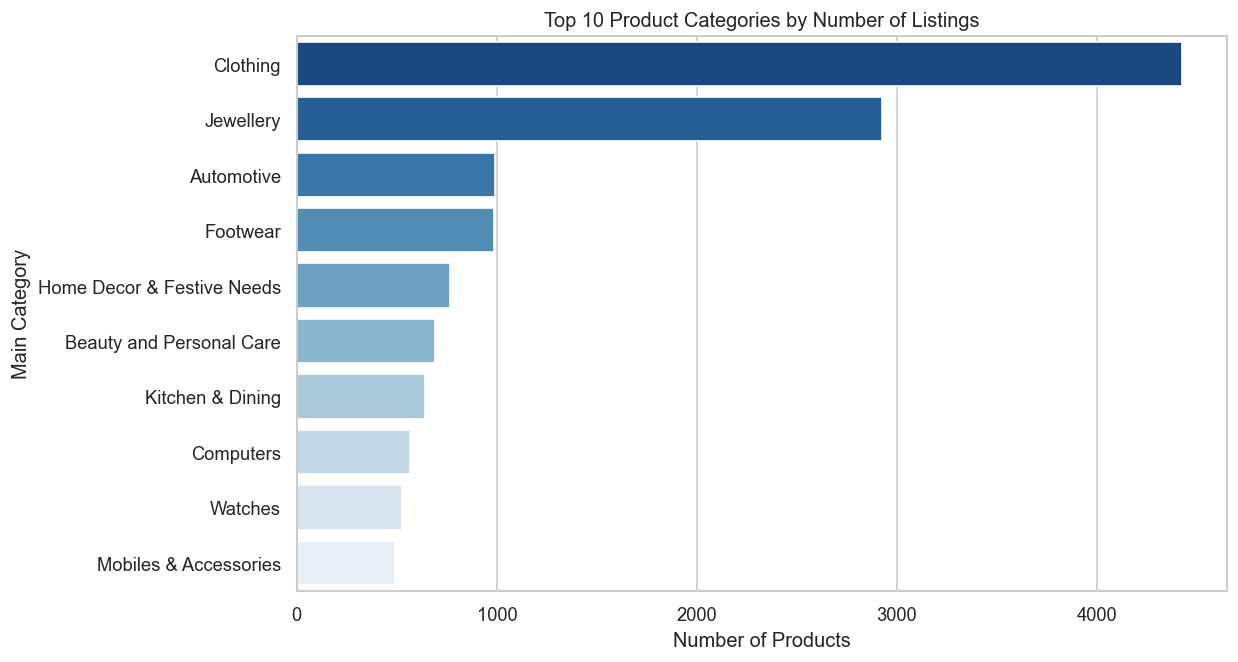

In [4]:
# ==========================================================
# Top Product Categories
# ==========================================================

top_categories = (
    df["main_category"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index,
    palette="Blues_r"
)

plt.title("Top 10 Product Categories by Number of Listings")

plt.xlabel("Number of Products")

plt.ylabel("Main Category")

plt.show()

## Observation

The catalogue is heavily concentrated in a small number of categories.

**Clothing** represents approximately **31%** of all product listings, making it the largest category in the catalogue.

This suggests that Flipkart's catalogue during the study period had a strong focus on fashion products, resulting in higher competition and greater pricing sensitivity within this segment.

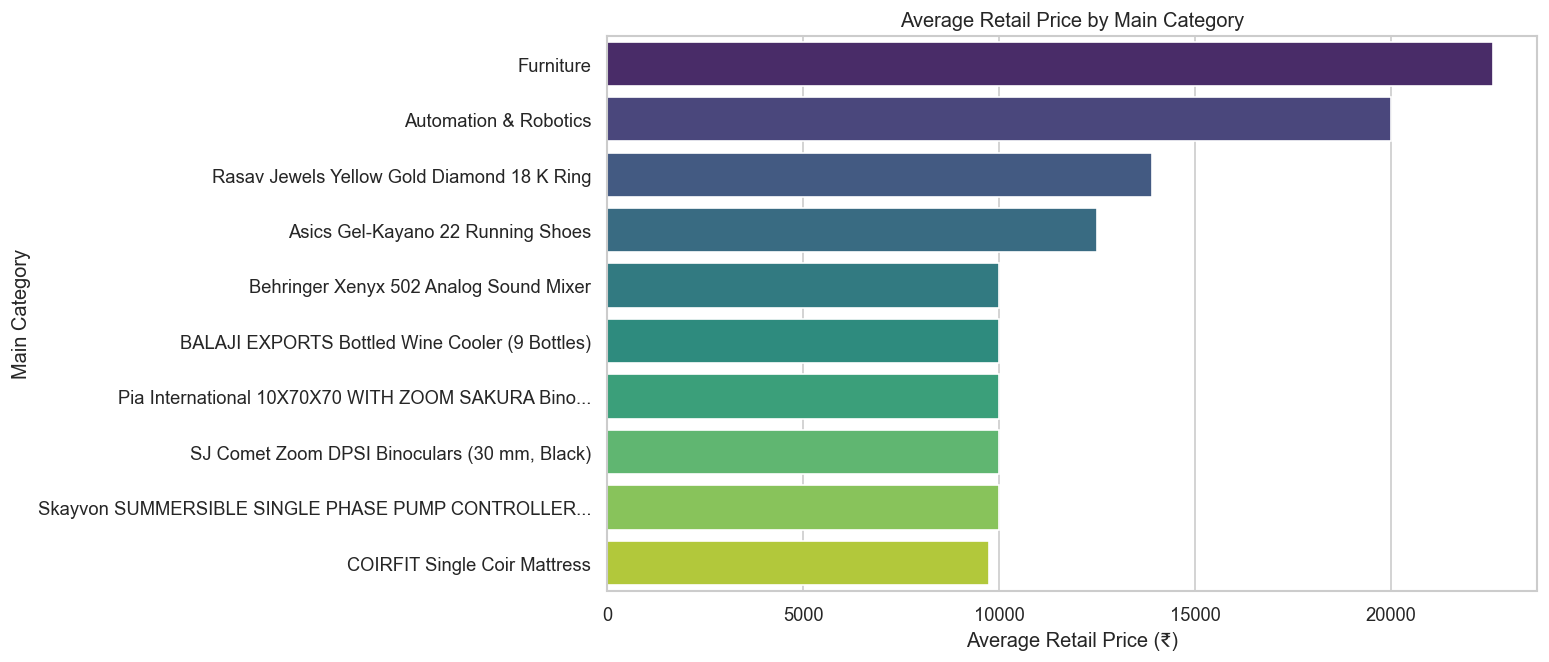

In [5]:
# ==========================================================
# Average Retail Price by Category
# ==========================================================

category_price = (
    df.groupby("main_category")["retail_price"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=category_price.values,
    y=category_price.index,
    palette="viridis"
)

plt.title("Average Retail Price by Main Category")

plt.xlabel("Average Retail Price (₹)")

plt.ylabel("Main Category")

plt.show()

# Price Distribution Analysis

Understanding the distribution of product prices helps identify the overall pricing strategy adopted by the marketplace.

Since product prices vary from ₹35 to over ₹5.7 lakh, the distribution is expected to be highly skewed. Therefore, both linear and logarithmic scales are used for better visualization.

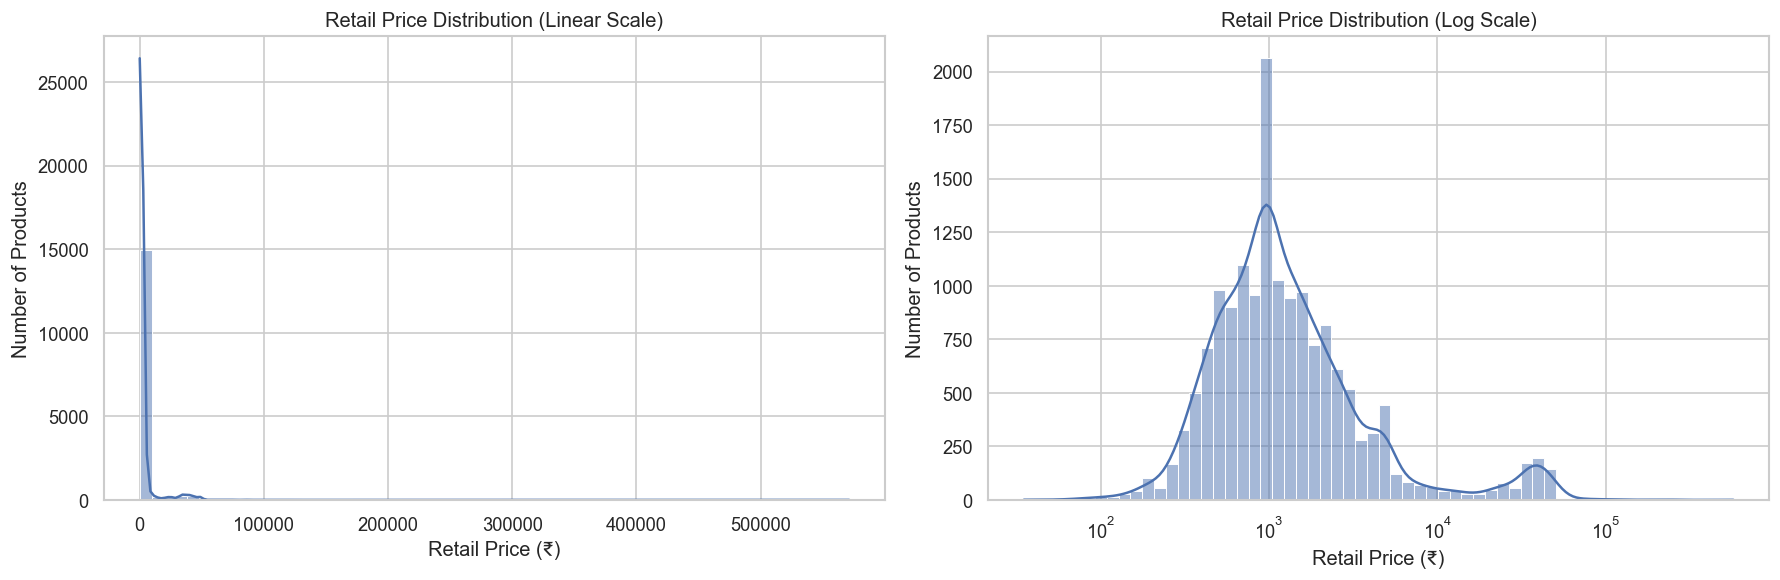

In [6]:
# ==========================================================
# Retail Price Distribution
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(15,5))

# Linear Scale
sns.histplot(
    df["retail_price"],
    bins=60,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Retail Price Distribution (Linear Scale)")
axes[0].set_xlabel("Retail Price (₹)")
axes[0].set_ylabel("Number of Products")

# Log Scale
sns.histplot(
    df["retail_price"],
    bins=60,
    kde=True,
    log_scale=True,
    ax=axes[1]
)

axes[1].set_title("Retail Price Distribution (Log Scale)")
axes[1].set_xlabel("Retail Price (₹)")
axes[1].set_ylabel("Number of Products")

plt.tight_layout()
plt.show()

## Observation

The retail price distribution is highly right-skewed.

Most products fall below ₹2,000, while only a small proportion of premium products extend into higher price ranges.

This indicates that Flipkart's catalogue primarily targets the mass-market segment while maintaining a limited premium product portfolio.

# Discount Strategy Analysis

Discounting is one of the primary pricing strategies used by e-commerce platforms.

This section examines how discounts are distributed across products and whether discount levels vary across categories and price segments.

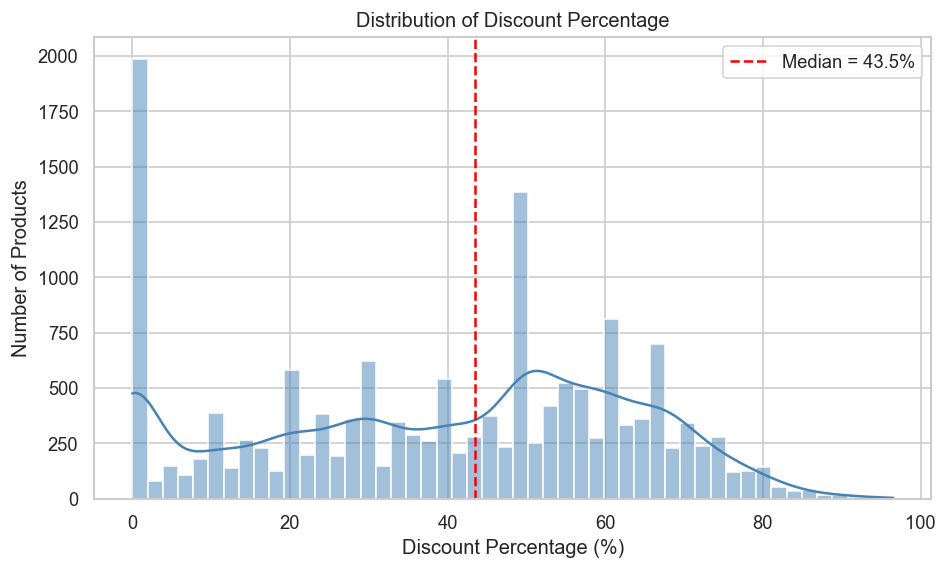

In [7]:
# ==========================================================
# Distribution of Discount Percentage
# ==========================================================

plt.figure(figsize=(9,5))

sns.histplot(
    df["discount_percentage"],
    bins=50,
    kde=True,
    color="steelblue"
)

plt.axvline(
    df["discount_percentage"].median(),
    color="red",
    linestyle="--",
    label=f"Median = {df['discount_percentage'].median():.1f}%"
)

plt.title("Distribution of Discount Percentage")

plt.xlabel("Discount Percentage (%)")

plt.ylabel("Number of Products")

plt.legend()

plt.show()

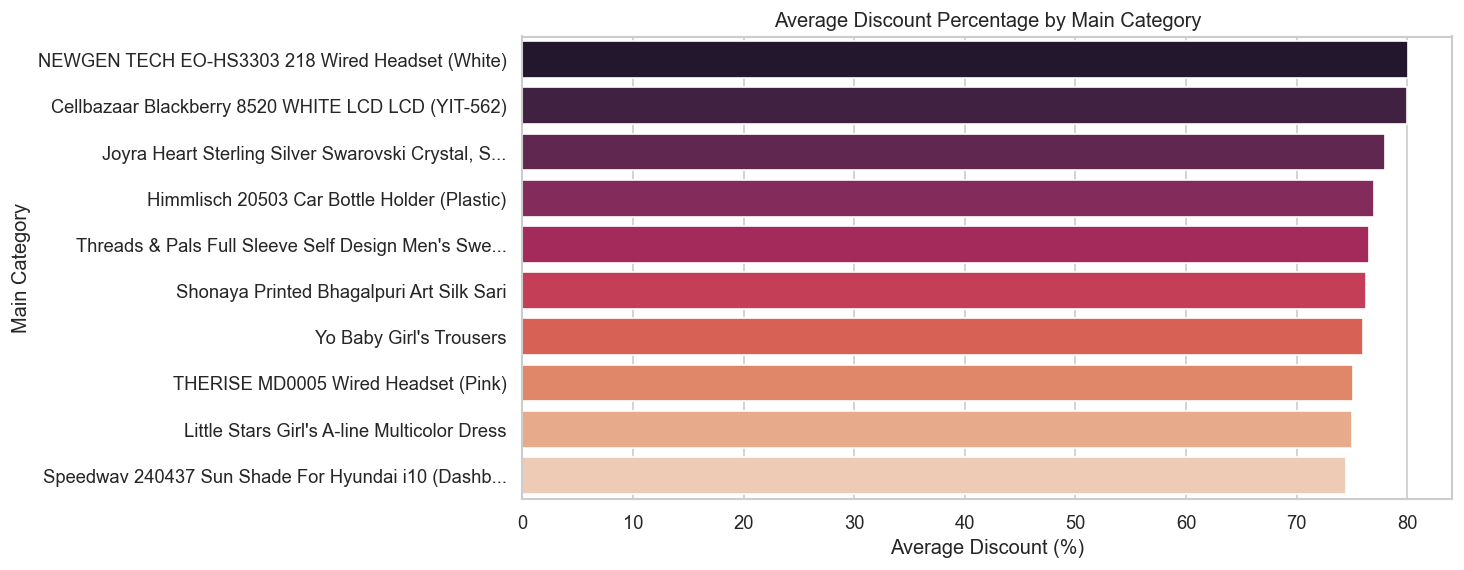

In [8]:
# ==========================================================
# Average Discount by Category
# ==========================================================

discount_category = (
    df.groupby("main_category")["discount_percentage"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=discount_category.values,
    y=discount_category.index,
    palette="rocket"
)

plt.title("Average Discount Percentage by Main Category")

plt.xlabel("Average Discount (%)")

plt.ylabel("Main Category")

plt.show()

## Observation

Average discounts remain relatively consistent across major product categories.

Rather than applying category-specific pricing strategies, the catalogue appears to follow a broadly standardized discounting approach.

This suggests that discounts are likely influenced more by seller-level pricing policies than by product category.

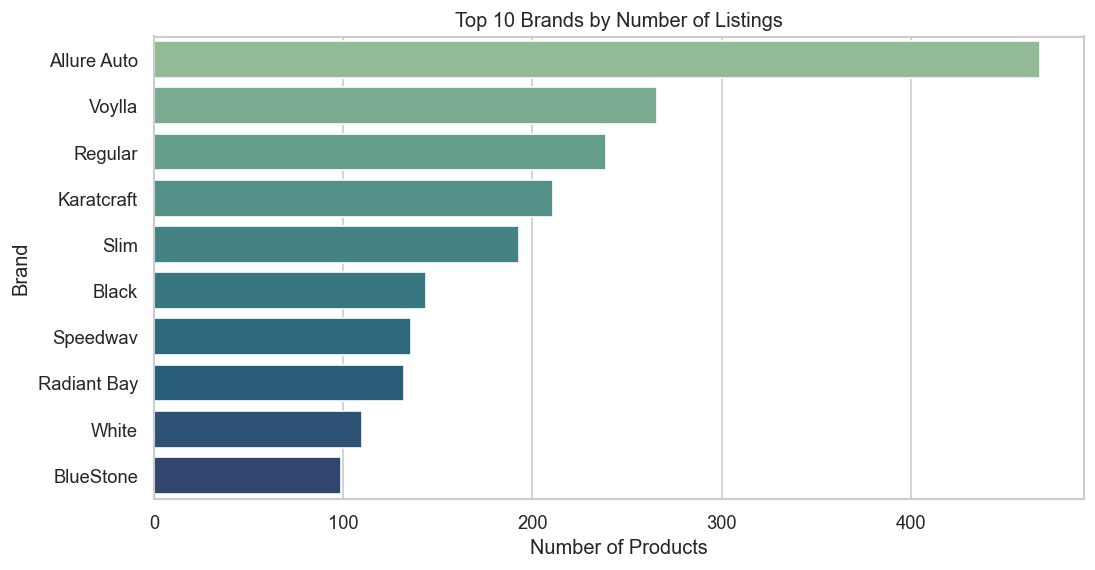

In [9]:
# ==========================================================
# Brand Analysis
# ==========================================================

df_real = df[
    ~df["brand"].isin(["Unknown", "Generic"])
]

top_brands = (
    df_real["brand"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_brands.values,
    y=top_brands.index,
    palette="crest"
)

plt.title("Top 10 Brands by Number of Listings")

plt.xlabel("Number of Products")

plt.ylabel("Brand")

plt.show()

Products with Ratings : 1620 (10.24%)


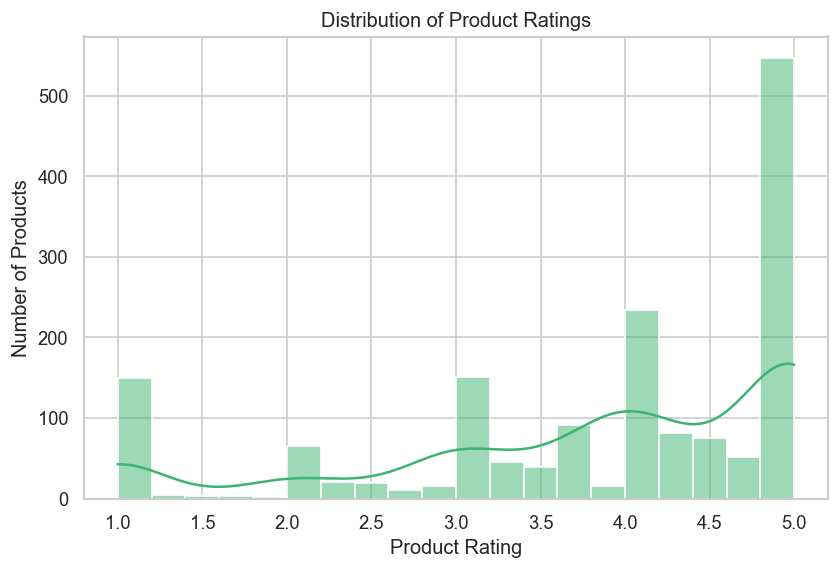

In [10]:
# ==========================================================
# Rating Analysis
# ==========================================================

rated_df = df[
    df["product_rating"].notna()
]

print(
    f"Products with Ratings : {len(rated_df)} "
    f"({len(rated_df)/len(df)*100:.2f}%)"
)

plt.figure(figsize=(8,5))

sns.histplot(
    rated_df["product_rating"],
    bins=20,
    kde=True,
    color="mediumseagreen"
)

plt.title("Distribution of Product Ratings")

plt.xlabel("Product Rating")

plt.ylabel("Number of Products")

plt.show()

# EDA Summary

## Key Findings

- The cleaned catalogue contains **15,827** unique product listings distributed across **251 main categories**.

- **Clothing** is the dominant category, accounting for approximately **31%** of all listings.

- Product prices exhibit a strong right-skewed distribution, with most products priced below **₹2,000**.

- The average discount across the catalogue is approximately **39.4%**, with only minor variation between categories.

- Products priced below **₹500** represent the largest price segment, indicating a strong focus on budget-conscious consumers.

- Approximately **29%** of products lack brand information, limiting the reliability of brand-level analysis.

- Only **10.2%** of products contain rating information, making customer satisfaction analysis statistically unreliable.

---

## Business Implications

The analysis indicates that Flipkart's marketplace during the study period primarily focused on affordable consumer products while maintaining standardized discount practices across categories.

Future business analysis would benefit significantly from the inclusion of sales transactions, customer purchases, review history, and seller-level performance metrics.